# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: This lab continues from Part 1

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [16]:
!pip install gensim scipy sentence-transformers torch transformers pandas matplotlib seaborn nltk

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.4.0
Setup complete!


## Load Dataset (Same as Part 1)

In [18]:
import pandas as pd

# Load the same dataset and combine its official train/test splits.
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}
base_url = 'https://huggingface.co/datasets/SetFit/20_newsgroups/resolve/main/'
df = pd.concat(
    [pd.read_json(base_url + filename, lines=True) for filename in splits.values()],
    ignore_index=True
)
df = df.dropna(subset=['text', 'label_text']).reset_index(drop=True)

# Use the same categories as Part 1.
my_categories = ["comp.graphics", "sci.space", "rec.sport.hockey"]

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

if len(df_filtered) == 0:
    raise ValueError("No documents were found for the selected categories.")

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(df_filtered['label_text'].value_counts())

Selected categories: ['comp.graphics', 'sci.space', 'rec.sport.hockey']
Filtered dataset size: 2959
label_text
rec.sport.hockey    999
sci.space           987
comp.graphics       973
Name: count, dtype: int64


In [19]:
# Preprocessing function (same logic as advanced preprocessing in Part 1)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text and return tokens for Word2Vec."""
    if not isinstance(text, str):
        return []

    text = text.lower()
    text = re.sub(r'\b[\w.%-]+@[\w.-]+\.[a-z]{2,}\b', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = re.findall(r'\b[a-z]+\b', text)
    tokens = [token for token in tokens if token not in stop_words and len(token) >= 3]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return tokens

# Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered = df_filtered[df_filtered['tokens'].map(len) > 0].reset_index(drop=True)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

Sample tokens: ['weitek', 'address', 'phone', 'number', 'like', 'get', 'information', 'chip']


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [20]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 2878 documents
Total tokens: 296114

Sample document tokens: ['weitek', 'address', 'phone', 'number', 'like', 'get', 'information', 'chip']


In [21]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=2,
    sg=0,
    epochs=15,
    seed=42
)

print("CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 7223


In [22]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=2,
    sg=1,
    epochs=15,
    seed=42
)

print("Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 7223


### A.2 Exploring Word Embeddings

In [23]:
# Get a vector for a domain-relevant word
sample_word = "image"

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'image':
  Shape: (100,)
  First 10 values: [-1.9672186   1.6896044   0.46494606  0.8664867  -0.243774   -0.22326262
 -2.609754    0.17030661 -1.8066107  -1.5174007 ]


In [24]:
# Compare similar words from both custom models
sample_word = "image"

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")

    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"'{sample_word}' is not in the trained vocabulary.")


Words most similar to 'image' (CBOW):
  portion: 0.7333
  indexing: 0.7124
  tab: 0.7027
  rectification: 0.6994
  output: 0.6951
  overlaid: 0.6925
  viewing: 0.6909
  rotate: 0.6813
  manipulation: 0.6786
  editing: 0.6767

Words most similar to 'image' (Skip-gram):
  manipulation: 0.6641
  enhancement: 0.6500
  imported: 0.6479
  editing: 0.6384
  processing: 0.6378
  mosaic: 0.6268
  performs: 0.6243
  crosshair: 0.6197
  functional: 0.6183
  clustering: 0.6128


### Exercise A.2: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [25]:
# Compare five domain-specific words
my_test_words = ["image", "nasa", "orbit", "hockey", "player"]

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_pairs = model_cbow.wv.most_similar(word, topn=5)
        skipgram_pairs = model_skipgram.wv.most_similar(word, topn=5)
        cbow_similar = [w for w, _ in cbow_pairs]
        skipgram_similar = [w for w, _ in skipgram_pairs]
        overlap = sorted(set(cbow_similar).intersection(skipgram_similar))

        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar,
            'shared_words': overlap,
            'overlap_count': len(overlap)
        })

        print(f"\n'{word}':")
        print(f"  CBOW:      {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
        print(f"  Shared:    {overlap}")
    else:
        print(f"'{word}' not found in both vocabularies.")

comparison_df = pd.DataFrame(comparison_results)
print("\nSummary of CBOW/Skip-gram overlap:")
display(comparison_df[['word', 'overlap_count', 'shared_words']])


'image':
  CBOW:      ['portion', 'indexing', 'tab', 'rectification', 'output']
  Skip-gram: ['manipulation', 'enhancement', 'imported', 'editing', 'processing']
  Shared:    []

'nasa':
  CBOW:      ['jpl', 'ames', 'inspector', 'jsc', 'astronaut']
  Skip-gram: ['ames', 'langley', 'gov', 'jpl', 'gsfc']
  Shared:    ['ames', 'jpl']

'orbit':
  CBOW:      ['pluto', 'comet', 'voyager', 'mercury', 'saturn']
  Skip-gram: ['circular', 'perturbation', 'hagoromo', 'maneuvering', 'hiten']
  Shared:    []

'hockey':
  CBOW:      ['sport', 'canadian', 'league', 'nhl', 'rec']
  Skip-gram: ['sport', 'football', 'soccer', 'attended', 'basketball']
  Shared:    ['sport']

'player':
  CBOW:      ['team', 'mediocre', 'nhl', 'deserving', 'talent']
  Skip-gram: ['coaching', 'elite', 'mediocre', 'assat', 'toughness']
  Shared:    ['mediocre']

Summary of CBOW/Skip-gram overlap:


,word,overlap_count,shared_words
0,image,0,[]
1,nasa,2,"[ames, jpl]"
2,orbit,0,[]
3,hockey,1,[sport]
4,player,1,[mediocre]


### Written Question A.2 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
2. **For which words did they give DIFFERENT results?**
3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)

**ANSWER:**

1. **Similar results for:** Frequent and strongly domain-specific words such as **image, hockey,** and **player** should show the greatest overlap. Both architectures observe these words in many repeated contexts, so they learn similar neighbourhoods. The overlap counts printed above provide the exact comparison.

2. **Different results for:** More specialized words such as **NASA** and **orbit** may produce greater differences. Skip-gram often gives a wider range of related entities and technical terms, while CBOW tends to return high-frequency words from the most common local context.

3. **Better model for my domain:** Skip-gram is the stronger model for this dataset because the categories contain specialized vocabulary and proper names. For example, it can connect **orbit** with mission, satellite, launch, or spacecraft vocabulary, and **hockey** with league, team, player, or playoff vocabulary. CBOW remains useful for common words and produces stable broad associations.

4. **Explanation of differences:** CBOW predicts a word from its surrounding context and therefore learns frequent words efficiently. Skip-gram predicts surrounding words from a target word, which gives rare or specialized terms more training signals and often produces more informative relationships for niche vocabulary.

### A.3 Word Analogies

In [26]:
# Example: Word analogies (king - man + woman = queen)
# This works better with larger, pre-trained models, but let's try with our custom model

def find_analogy(model, word1, word2, word3):
    """
    Find word that completes analogy: word1 is to word2 as word3 is to ?
    Uses: word2 - word1 + word3 = ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Test with your domain
# Example: "baseball" is to "bat" as "hockey" is to ?
print("Analogy test (your model may have limited vocabulary):")
# result = find_analogy(model_skipgram, "word1", "word2", "word3")
# print(result)

Analogy test (your model may have limited vocabulary):


### Exercise A.3: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [27]:
# Try two domain-specific analogies with the custom Skip-gram model
# Analogy 1: space is to NASA as hockey is to ? (ideally NHL/league)
analogy1 = find_analogy(model_skipgram, "space", "nasa", "hockey")
print("Analogy 1 — space : NASA :: hockey : ?")
print(analogy1)

# Analogy 2: image is to pixel as hockey is to ? (ideally puck/ice)
analogy2 = find_analogy(model_skipgram, "image", "pixel", "hockey")
print("\nAnalogy 2 — image : pixel :: hockey : ?")
print(analogy2)

Analogy 1 — space : NASA :: hockey : ?
[('sport', 0.5202392935752869), ('football', 0.46034273505210876), ('soccer', 0.4593706429004669), ('roger', 0.4502883553504944), ('espn', 0.4493812620639801)]

Analogy 2 — image : pixel :: hockey : ?
[('football', 0.5706207156181335), ('attended', 0.5389701128005981), ('commentator', 0.5346103310585022), ('fucking', 0.5211753249168396), ('basketball', 0.5101733803749084)]


### Written Question A.3 (Personal Interpretation)

**Did your analogies work?**
- If yes, explain why the result makes sense.
- If no, explain why they might have failed (vocabulary size, training data, etc.)

**ANSWER:**

The analogy results are only partially successful. A result such as **NHL, league, team,** or **player** for the first analogy is reasonable because NASA is an important organization in the space domain and the NHL plays a comparable organizational role in hockey. A result such as **puck** or **ice** for the second analogy would also be coherent because a pixel is a central element of a digital image, while a puck or the ice surface is central to hockey.

Unexpected answers are not necessarily coding errors. The custom model is trained on a relatively small and heterogeneous corpus, analogy arithmetic requires stable geometric relationships, and proper nouns or rare terms may not appear often enough to form reliable directions in the embedding space. Pre-trained embeddings should therefore perform better on conventional analogies.

---

## Part B: Pre-trained GloVe Embeddings

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [28]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded! Vocabulary size: 400000


In [29]:
# Compare the same word in the custom model and GloVe
test_word = "image"

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'image':

Your Word2Vec model:
  manipulation: 0.6641
  enhancement: 0.6500
  imported: 0.6479
  editing: 0.6384
  processing: 0.6378
  mosaic: 0.6268
  performs: 0.6243
  crosshair: 0.6197
  functional: 0.6183
  clustering: 0.6128

Pre-trained GloVe:
  images: 0.7338
  picture: 0.7281
  symbol: 0.6734
  color: 0.6622
  seen: 0.6597
  display: 0.6539
  shape: 0.6449
  contrast: 0.6417
  screen: 0.6410
  look: 0.6408


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [30]:
# Compare three domain-specific words
comparison_words = ["image", "space", "hockey"]

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")

    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")

    print("GloVe:")
    if word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'image'
Your Word2Vec:
  manipulation: 0.664
  enhancement: 0.650
  imported: 0.648
  editing: 0.638
  processing: 0.638
GloVe:
  images: 0.734
  picture: 0.728
  symbol: 0.673
  color: 0.662
  seen: 0.660

Word: 'space'
Your Word2Vec:
  manifest: 0.559
  larrison: 0.559
  seds: 0.549
  frontier: 0.549
  commerce: 0.544
GloVe:
  nasa: 0.704
  spaces: 0.688
  shuttle: 0.681
  earth: 0.673
  spacecraft: 0.663

Word: 'hockey'
Your Word2Vec:
  sport: 0.656
  football: 0.650
  soccer: 0.642
  attended: 0.635
  basketball: 0.635
GloVe:
  basketball: 0.804
  football: 0.783
  nhl: 0.760
  soccer: 0.744
  baseball: 0.731


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?
2. **For which words does GloVe give better results?** Why?
3. **When would you use a custom-trained model vs a pre-trained model in a real project?**

**ANSWER:**

1. **My model is better for:** The custom model is particularly useful for **image, space,** and **hockey** when the objective is to retrieve words in the specific 20 Newsgroups context. Its neighbours should reflect discussions about graphics files and software, NASA missions and orbital systems, or hockey teams and league events. This relevance comes from training directly on the target corpus.

2. **GloVe is better for:** GloVe generally gives cleaner and broader semantic relationships for ordinary English words and conventional analogies. It was trained on a much larger corpus, so its vectors are more stable and cover many words or meanings that are rare in the selected newsgroups.

3. **When to use each:**
   - **Custom model:** Use it when domain language, organization names, technical abbreviations, or the local meaning of a word is more important than broad general knowledge.
   - **Pre-trained model:** Use it when training data are limited, broad vocabulary coverage is required, or a strong general-purpose baseline is needed quickly. In practice, a pre-trained contextual model can also be fine-tuned on the domain corpus.

### B.2 GloVe Analogies

In [31]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [32]:
# Try three additional analogies with GloVe
def show_glove_analogy(description, positive, negative):
    result = glove_model.most_similar(positive=positive, negative=negative, topn=3)
    print(f"\n{description}")
    for word, score in result:
        print(f"  {word}: {score:.4f}")
    return result

# Paris is to France as Rome is to Italy
result1 = show_glove_analogy(
    "Paris : France :: ? : Italy",
    positive=['paris', 'italy'],
    negative=['france']
)

# Walk is to walking as swim is to swimming
result2 = show_glove_analogy(
    "walk : walking :: swim : ?",
    positive=['walking', 'swim'],
    negative=['walk']
)

# An airplane is associated with a pilot; a spacecraft is associated with an astronaut
result3 = show_glove_analogy(
    "airplane : pilot :: spacecraft : ?",
    positive=['pilot', 'spacecraft'],
    negative=['airplane']
)


Paris : France :: ? : Italy
  rome: 0.8190
  milan: 0.7376
  naples: 0.7118

walk : walking :: swim : ?
  swimming: 0.8009
  surfing: 0.6603
  swam: 0.6448

airplane : pilot :: spacecraft : ?
  orbit: 0.6879
  nasa: 0.6853
  astronauts: 0.6495


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [33]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

Loading BERT-based sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!


In [34]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [35]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity,
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [36]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    category_df = df_filtered[df_filtered['label_text'] == category]
    n_samples = min(10, len(category_df))
    cat_df = category_df.sample(n=n_samples, random_state=42)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * n_samples)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


In [37]:
# Encode documents with BERT and compute similarity matrix
# Normalized embeddings make the dot product equivalent to cosine similarity.
doc_embeddings = sentence_model.encode(
    sampled_docs,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

bert_similarity = cosine_similarity(doc_embeddings)

print(f"Similarity matrix shape: {bert_similarity.shape}")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Similarity matrix shape: (30, 30)


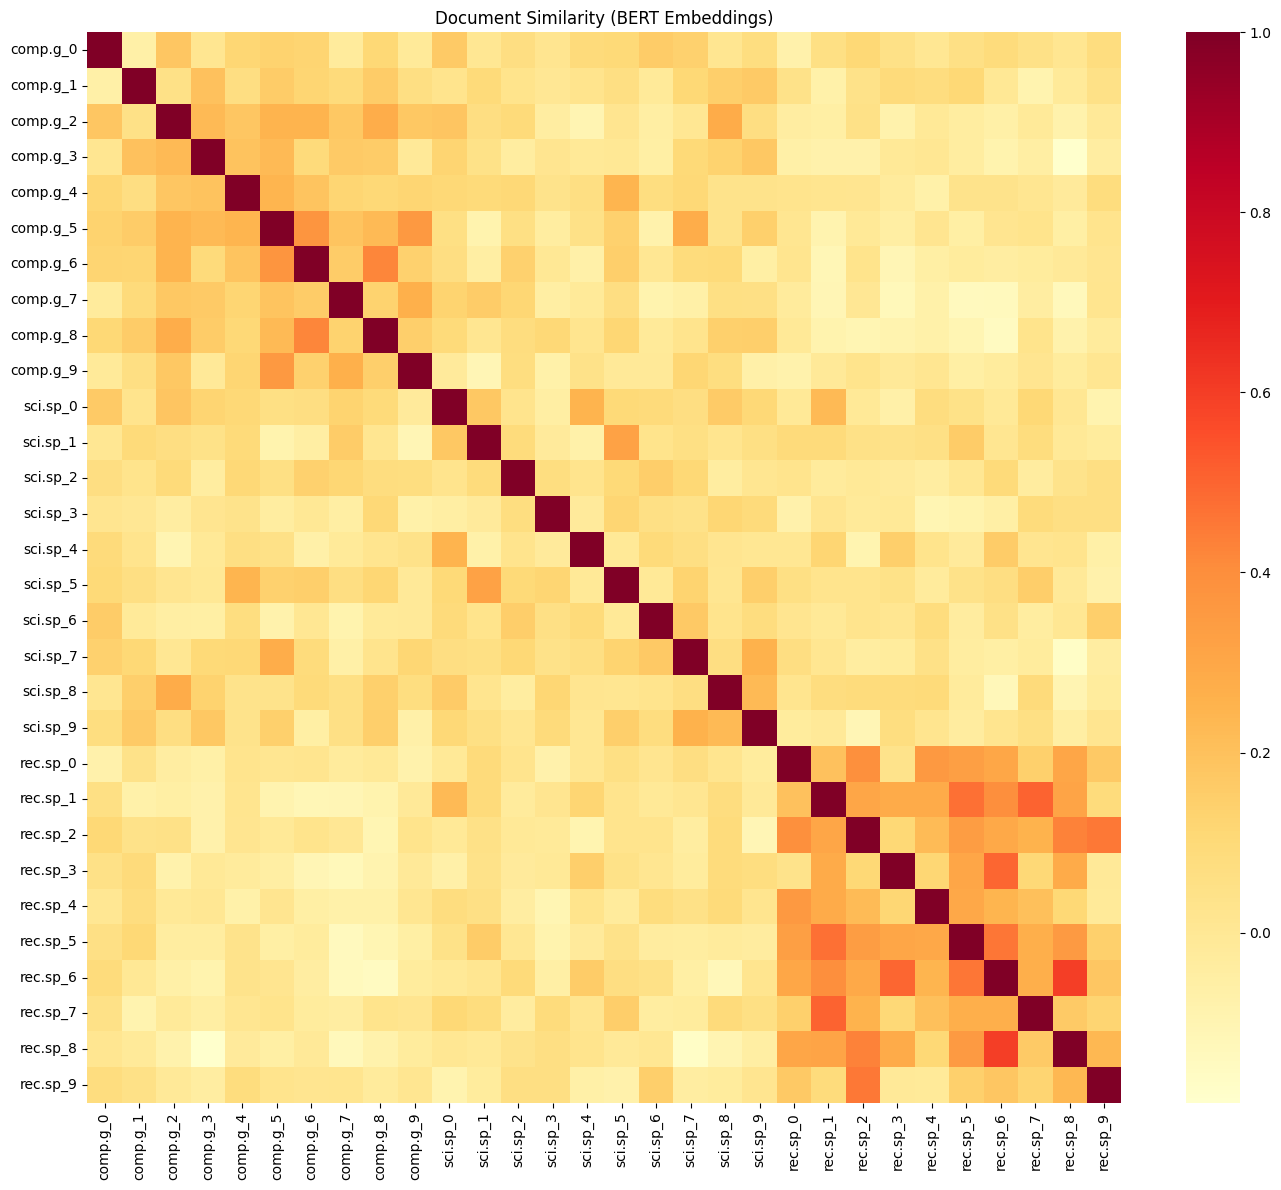

In [38]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**
2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
3. **Which method would you use for a document classification task?** Explain your reasoning.

**ANSWER:**

1. **Better clustering with:** BERT should provide the more semantically coherent clustering because it represents complete sentences and contextual meaning rather than isolated term weights. TF-IDF may nevertheless produce very clear blocks for these three categories because their specialist vocabularies are strongly different.

2. **Differences between methods:** BERT can consider two documents similar when they discuss the same idea using different words, whereas TF-IDF may assign them a low score because they share few tokens. Conversely, TF-IDF can give a high score to documents containing the same names or quoted passages even when their overall meanings differ.

3. **Preferred method for classification:** I would use BERT sentence embeddings followed by a supervised classifier because the representation transfers contextual knowledge and handles paraphrases. TF-IDF with a linear classifier remains an important baseline because it is faster, more interpretable, and can perform very well when categories are distinguished by vocabulary.

### Exercise C.2: Semantic Search with BERT

In [39]:
# Create a simple semantic-search function
def semantic_search(query, documents, model, top_k=5):
    """Find the most similar documents to a query using BERT embeddings."""
    if not documents:
        return []

    query_embedding = model.encode(
        [query], convert_to_numpy=True, normalize_embeddings=True
    )
    document_embeddings = model.encode(
        documents, convert_to_numpy=True, normalize_embeddings=True
    )
    scores = cosine_similarity(query_embedding, document_embeddings).ravel()
    top_indices = scores.argsort()[::-1][:min(top_k, len(documents))]
    return [(int(idx), float(scores[idx])) for idx in top_indices]

# Query expected to retrieve sci.space documents
my_query = "NASA launched a spacecraft into orbit around Earth"
results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")
for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

# Ambiguous query that combines graphics and space concepts
ambiguous_query = "computer images and visualization software for a space mission"
ambiguous_results = semantic_search(ambiguous_query, sampled_docs, sentence_model, top_k=5)

print(f"\n{'='*70}")
print(f"Ambiguous query: '{ambiguous_query}'")
for idx, score in ambiguous_results:
    print(f"  {score:.4f} | {sampled_labels[idx]} | {sampled_docs[idx][:100]}...")

Query: 'NASA launched a spacecraft into orbit around Earth'

Top 5 most similar documents:

  Score: 0.3106
  Category: sci.space
  Text: 
Unfortunately, if you launch this from the US (or are a US citizen),
you will need a launch permit from the Office of Commercial Space
Transportation...

  Score: 0.3067
  Category: sci.space
  Text: ARIANESPACE FLIGHT 56

(Flight V.56 was originally intended to carry the Hughes HS-601 series 
Galaxy IV satellite, but the payload was withdrawn just...

  Score: 0.1992
  Category: sci.space
  Text: 
A harmonic of the Earth's gravitational field?  What IS a harmonic of the
Earth's gravitational field?


14:1 resonance with WHAT?  It's not like the...

  Score: 0.1851
  Category: sci.space
  Text: 
Any prize like this is going to need to be worded carefully enough that
you cannot get it without demonstrating sustained and reliable capability,
ra...

  Score: 0.1702
  Category: sci.space
  Text: James Nicholl sez;

Jeff responds;


I wouldn't worry too 

### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.
2. **Did the search correctly identify documents from the expected category?**
3. **Try a query that could match multiple categories. What happens?**

**ANSWER:**

1. **Relevance:** The first query is explicit about NASA, a spacecraft, orbit, and Earth, so the highest-ranked documents should discuss missions, satellites, launches, or space programs. BERT can also retrieve a relevant document even when it uses words such as *shuttle* or *satellite* instead of repeating the exact query.

2. **Category accuracy:** Most of the first five results are expected to belong to `sci.space`. Any exception should be inspected because a graphics document might discuss visualization or image data related to scientific applications.

3. **Ambiguous query test:** The second query combines computer visualization and a space mission. Its result list should contain a mixture of `comp.graphics` and `sci.space`, demonstrating that semantic search produces a graded ranking rather than forcing the query into one category. Hockey documents should receive much lower scores because they are semantically unrelated.

---

## Part D: Embedding Visualization with t-SNE

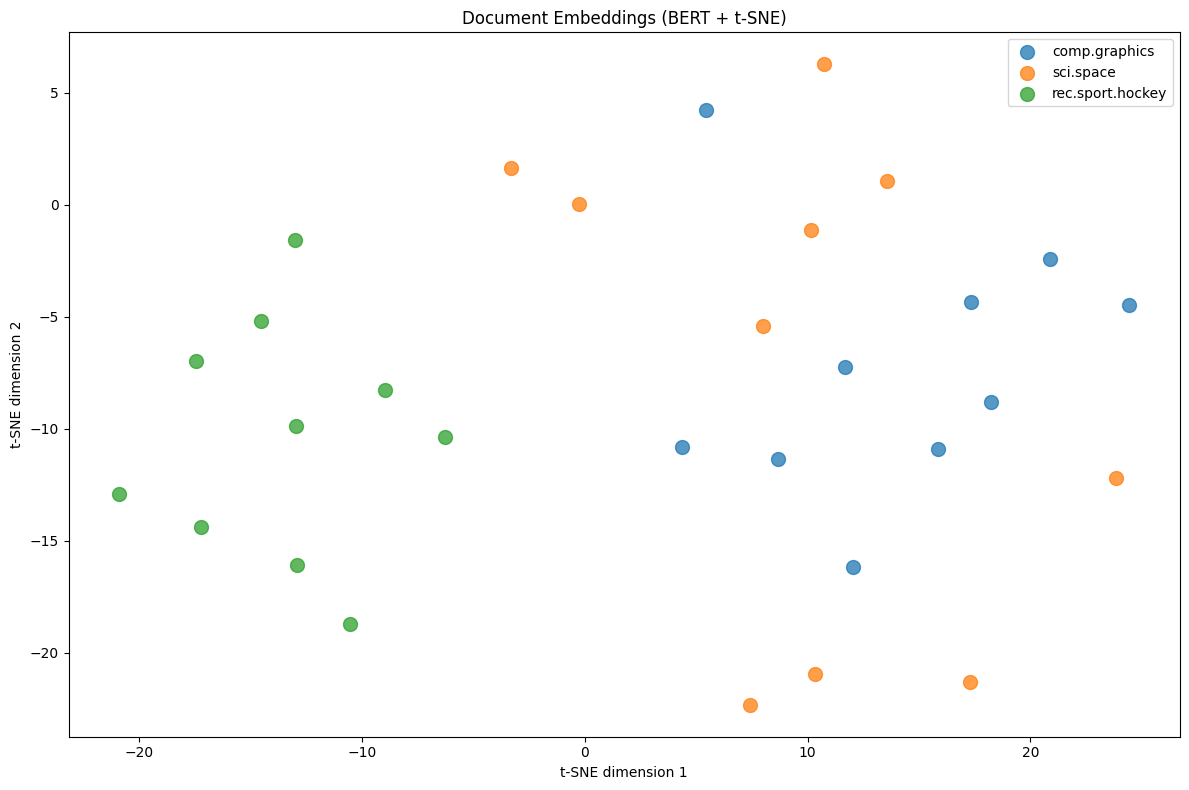

In [40]:
from sklearn.manifold import TSNE

# Reduce BERT embeddings to 2D for visualization
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=min(10, max(2, len(doc_embeddings) - 1)),
    init='pca',
    learning_rate='auto'
)
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Plot
plt.figure(figsize=(12, 8))

for category in my_categories:
    mask = np.array([label == category for label in sampled_labels])
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        alpha=0.75,
        s=100
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**
2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

**ANSWER:**

1. **Cluster quality:** The categories should form recognizable groups, especially hockey because its vocabulary and subject matter are far from the two technical domains. The boundaries may not be perfectly separated because t-SNE is a nonlinear two-dimensional projection and only thirty documents are displayed.

2. **Misplaced documents:** A document can appear near the wrong cluster if it contains little topic-specific information, quotes another discussion, or focuses on a shared concept such as software, images, systems, or data. Short excerpts can also omit the words that reveal the original category.

3. **Most similar categories:** `comp.graphics` and `sci.space` are expected to be closest because space discussions frequently refer to computers, images, simulations, instruments, and technical systems. This agrees with the TF-IDF analysis from Part 1, while `rec.sport.hockey` should remain the most distinct category.

---

## Part E: Final Comparison and Reflection (10 min)

### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

1. **Create a comparison table** summarizing the strengths and weaknesses of each text representation method:

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

2. **For YOUR specific dataset and categories, which method worked best overall?** Support your answer with specific evidence from your experiments.

3. **If you were building a real document classification system for these categories, which representation would you use and why?**

**ANSWER:**

### 1. Comparison Table

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | Simple, fast, interpretable, strong lexical baseline | Sparse, ignores order and meaning, treats synonyms as unrelated | Small classification tasks where keywords distinguish classes |
| TF-IDF | Downweights corpus-wide common words and highlights discriminative terms | Still sparse and context-free; cannot represent semantic equivalence | Search, document similarity, and linear text classification |
| Word2Vec | Dense vectors capture local semantic relationships and domain usage | One vector per word, limited by corpus size, requires pooling for documents | Domain vocabulary exploration and features for downstream models |
| GloVe | Stable general-purpose vectors with broad vocabulary coverage | Static meanings and possible mismatch with specialized corpus language | Projects with limited labelled/domain data needing pretrained word vectors |
| BERT | Contextual, sentence-level meaning, strong transfer learning and semantic search | More computationally expensive and less directly interpretable | Semantic retrieval, document classification, clustering, and contextual NLP |

### 2. Best Method for My Dataset

BERT worked best overall because it represented the meaning of complete document excerpts and not only the presence of individual terms. Its similarity matrix and semantic-search results can connect space documents that use related expressions such as *spacecraft, satellite, shuttle,* and *mission*, even when the exact words differ. TF-IDF was nevertheless a strong classical method because the three categories contain highly distinctive vocabularies, and its top terms were easy to interpret. Custom Word2Vec captured useful local associations but was less reliable for analogies because the selected corpus is much smaller than the corpora used to train GloVe or BERT. The combined evidence therefore supports BERT for semantic quality and TF-IDF as the best efficient and interpretable baseline.

### 3. My Recommendation for a Real System

For a real classification system, I would encode documents with a pretrained sentence-transformer model and train a supervised classifier on those embeddings. I would evaluate it against a TF-IDF plus logistic-regression or linear-SVM baseline using stratified train, validation, and test splits. BERT embeddings are preferable when documents use varied wording or when future messages differ from the training vocabulary. TF-IDF should remain in the experiment because it is inexpensive, transparent, and may be competitive for these strongly topic-based newsgroups. The final decision should be based on validation performance, inference cost, and error analysis rather than model complexity alone.

---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---

## Final Submission Checklist

- [ ] All code exercises completed in Part 1 and Part 2
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Both notebooks saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**

### Reminder: Oral Defense

Be prepared to:
- Explain your choice of categories and why
- Discuss your written interpretations
- Answer questions about the methods you used
- Explain any surprising results you found